In [1]:
from toolbox_ziyan import *
import warnings
import random
import os
import pandas as pd
import numpy as np
import cv2
import librosa
import time
import re
from timeout_decorator import timeout

import matplotlib.pyplot as plt
import numpy as np
from ConfigSpace import (
    Categorical,
    Configuration,
    ConfigurationSpace,
    EqualsCondition,
    Float,
    InCondition,
    Integer,
)
from sklearn.datasets import load_digits
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.metrics import cohen_kappa_score, accuracy_score
import xgboost as xgb

from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.base import BaseEstimator
from sklearn.preprocessing import StandardScaler
from skopt.callbacks import DeadlineStopper

from smac import MultiFidelityFacade as MFFacade
from smac import Scenario
from smac.facade import AbstractFacade
from smac.intensifier.hyperband import Hyperband
from smac.intensifier.successive_halving import SuccessiveHalving

import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
from torch.utils.data import Dataset
import torch.optim as optim
import torchaudio
import torchaudio.transforms as trans


import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)



In [2]:
class FSDKaggle18Dataset(Dataset):
    """
    This class is based on torch.utils.data.Dataset for loading the entire
    FSDKaggle18 Dataset using native torch and torchaudio primitives.

    ----------------------------------------------------
    Input parameters:
      annotations_file: str
      Path to the file containing the ground truths

      audio_dir: str
      Path to the folder containing the audio files

    Returns:
    instance of torch.utils.data.Dataset() returning the audio file together with it's corresponding label.

    """

    def __init__(self, annotations_file, audio_dir):
        # loop through the csv entries and only add entries from folders in the folder list
        self.annotations = pd.read_csv(annotations_file)
        self.audio_dir = audio_dir
        data_final = []
        for filepaths in os.listdir(self.audio_dir):
            data_final.append(os.path.join(self.audio_dir, filepaths))
        self.data_final = data_final

    def __getitem__(self, index):
        audio_sample_path = self._get_sample_path(index)
        label = self._get_label_(index)
        signal, sr = torchaudio.load(audio_sample_path)
        return signal, sr, label

    def _get_sample_path(self, index):
        return os.path.join(self.audio_dir, self.annotations.iloc[index, 0])

    def _get_label_(self, index1):
        labels_to_index = {
            "Acoustic_guitar": 0,
            "Applause": 1,
            "Bass_drum": 2,
            "Cello": 3,
            "Clarinet": 4,
            "Double_bass": 5,
            "Fart": 6,
            "Fireworks": 7,
            "Flute": 8,
            "Hi-hat": 9,
            "Laughter": 10,
            "Saxophone": 11,
            "Shatter": 12,
            "Snare_drum": 13,
            "Squeak": 14,
            "Tearing": 15,
            "Trumpet": 16,
            "Violin_or_fiddle": 17,
        }
        get_labels = self.annotations["label"].replace(labels_to_index).to_list()
        y_value = get_labels[index1]
        return y_value

    def __len__(self):
        return len(os.listdir(self.audio_dir))


def load_fsdk18(path_recordings, labels_file, label_arr, feature_type="spectrogram"):

    audio_data = []  # audio data
    x_audio = []  # STFT spectrogram
    x_audio_mini = []  # resized image, 32*32
    y_number = []  # label of number  # label of speaker
    if feature_type == "spectrogram":
        a = trans.Spectrogram(n_fft=128, normalized=True)
    elif feature_type == "melspectrogram":
        a = trans.MelSpectrogram(n_fft=128, normalized=True)
    elif feature_type == "mfcc":
        a = trans.MFCC(n_mfcc=128)
    for i in path_recordings:
        x, sr = librosa.load(i, sr=44100)
        i = i[-12:]
        x_stft_db = a(torch.tensor(x)).numpy()
        # Convert an amplitude spectrogram to dB-scaled spectrogram
        x_stft_db_mini = cv2.resize(x_stft_db, (32, 32))  # Resize into 32 by 32
        get_label_location = int(
            labels_file.fname.index[labels_file["fname"] == i].to_numpy()
        )

        y_n = label_arr[get_label_location]  # label number
        # Check if the label is in the labels_to_index dictionary
        if y_n in labels_to_index.values():
            audio_data.append(x)
            x_audio.append(x_stft_db)
            x_audio_mini.append(x_stft_db_mini)
            y_number.append(y_n)

    x_audio_mini = np.array(x_audio_mini)
    y_number = np.array(y_number).astype(int)

    return x_audio_mini, y_number

def combinations_45(iterable, r):
    """Extracts 45 combinations from given list"""
    pool = tuple(iterable)
    n = len(pool)
    if r > n:
        return
    indices = list(range(r))
    yield tuple(pool[i] for i in indices)
    count = 0
    while count < 44:
        count += 1
        for i in reversed(range(r)):
            if indices[i] != i + n - r:
                break
        else:
            return
        indices[i] += 1
        for j in range(i + 1, r):
            indices[j] = indices[j - 1] + 1
        yield tuple(pool[i] for i in indices)

torch.multiprocessing.freeze_support()

n_classes = 3 #int(args.m)
feature_type = 'spectrogram'#str(args.f)

train_folder = '/Users/whhqund/Desktop/JHU/NeuroData/df-dn-paper/benchmarks/audition/FSDKaggle2018.audio_data'#str(args.data)
train_label = pd.read_csv(str('/Users/whhqund/Desktop/JHU/NeuroData/df-dn-paper/benchmarks/audition/labels.csv'))#args.labels))

# select subset of data that only contains 300 samples per class
labels_chosen = train_label[
    train_label["label"].map(train_label["label"].value_counts() >= 0)
]

training_files = []
for file in os.listdir(train_folder):
    for x in labels_chosen.fname.to_list():
        if file.endswith(x):
            training_files.append(file)

path_recordings = []
for audiofile in training_files:
    path_recordings.append(os.path.join(train_folder, audiofile))

# convert selected label names to integers
labels_to_index = {
    "Acoustic_guitar": 0,
    "Applause": 1,
    "Bass_drum": 2,
    "Cello": 3,
    "Clarinet": 4,
    "Double_bass": 5,
    "Fart": 6,
    "Fireworks": 7,
    "Flute": 8,
    "Hi-hat": 9,
    "Laughter": 10,
    "Saxophone": 11,
    "Shatter": 12,
    "Snare_drum": 13,
    "Squeak": 14,
    "Tearing": 15,
    "Trumpet": 16,
    "Violin_or_fiddle": 17,
}

# encode labels to integers
get_labels = labels_chosen["label"].replace(labels_to_index).to_list()

 # data is normalized upon loading
# load dataset
x_spec, y_number = load_fsdk18(
    path_recordings, labels_chosen, get_labels, feature_type
)

nums = list(range(18))

# define samples space
samples_space = np.geomspace(10, 450, num=6, dtype=int)
# samples_space = np.geomspace(30, 1500, num=6, dtype=int)

# define path, samples space and number of class combinations
if feature_type == "melspectrogram":
    quit(0)
    prefix = args.m + "_class_mel/"
elif feature_type == "spectrogram":
    # prefix = args.m + "_class/"
    prefix = 'spectrogram' + '_class/'
elif feature_type == "mfcc":
    quit(0)
    prefix = args.m + "_class_mfcc/"

# create list of classes with const random seed
random.Random(5).shuffle(nums)
classes_space = list(combinations_45(nums, n_classes))

# scale the data
x_spec = scale(x_spec.reshape(len(x_spec), -1), axis=1).reshape(len(x_spec), 32, 32)
y_number = np.array(y_number)

# need to take train/valid/test equally from each class
trainx, remainx, trainy, remainy = train_test_split(
    x_spec,
    y_number,
    shuffle=True,
    test_size=0.5,
    stratify=y_number,
)

testx, valx, testy, valy = train_test_split(
    remainx,
    remainy,
    shuffle=True,
    test_size=0.5,
    stratify=remainy,
)

# 3000 samples, 80% train is 2400 samples, 20% test
fsdk18_train_images = trainx.reshape(-1, 32 * 32)
fsdk18_train_labels = trainy.copy()
# reshape in 2d array
fsdk18_test_images = testx.reshape(-1, 32 * 32)
fsdk18_test_labels = testy.copy()
# validation set
fsdk18_valid_images = valx.reshape(-1, 32 * 32)
fsdk18_valid_labels = valy.copy()

scaler = StandardScaler()
train_images = scaler.fit_transform(fsdk18_train_images)
test_images = scaler.transform(fsdk18_test_images)
valid_images = scaler.transform(fsdk18_valid_images)

train_images = torch.FloatTensor(train_images).unsqueeze(1)
train_labels = torch.LongTensor(fsdk18_train_labels)
test_images = torch.FloatTensor(test_images).unsqueeze(1)
test_labels = torch.LongTensor(fsdk18_test_labels)
valid_images = torch.FloatTensor(valid_images).unsqueeze(1)
valid_labels = torch.LongTensor(fsdk18_valid_labels)

train_x = train_images
train_y = train_labels
test_x = test_images
test_y = test_labels
valid_x = valid_images
valid_y = valid_labels

In [5]:
def get_ece(predicted_posterior, predicted_label, true_label, num_bins=40):
    """
    Return expected calibration error (ECE)
    """
    poba_hist = []
    accuracy_hist = []
    bin_size = 1 / num_bins
    total_sample = len(true_label)
    posteriors = predicted_posterior.max(axis=1)

    score = 0
    for bin in range(num_bins):
        indx = np.where(
            (posteriors > bin * bin_size) & (posteriors <= (bin + 1) * bin_size)
        )[0]

        acc = (
            np.nan_to_num(np.mean(predicted_label[indx] == true_label[indx]))
            if indx.size != 0
            else 0
        )
        conf = np.nan_to_num(np.mean(posteriors[indx])) if indx.size != 0 else 0
        score += len(indx) * np.abs(acc - conf)

    score /= total_sample
    return score

In [6]:
class SimpleCNN32Filter(nn.Module):
    """
    Defines a simple CNN arhcitecture
    """

    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=10, stride=2)
        self.fc1 = nn.Linear(144 * 32, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = x.view(-1, 144 * 32)
        x = self.fc1(x)
        return x

In [7]:
class SimpleCNN32Filter2Layers(nn.Module):
    """
    Define a simple CNN arhcitecture with 2 layers
    """

    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, stride=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=5, stride=2)
        self.fc1 = nn.Linear(12 * 12 * 32, 100)
        self.fc2 = nn.Linear(100, num_classes)

    def forward(self, x):
        b = x.shape[0]
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(b, -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [8]:
class SimpleCNN32Filter5Layers(nn.Module):
    """
    Define a simple CNN arhcitecture with 5 layers
    """

    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(8192, 200)
        self.fc2 = nn.Linear(200, num_classes)
        self.maxpool = nn.MaxPool2d((2, 2))
        self.bn = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

    def forward(self, x):
        b = x.shape[0]
        x = F.relu(self.bn(self.conv1(x)))
        x = F.relu(self.bn(self.conv2(x)))
        x = self.maxpool(x)
        x = F.relu(self.bn2(self.conv3(x)))
        x = F.relu(self.bn2(self.conv4(x)))
        x = F.relu(self.bn3(self.conv5(x)))
        x = self.maxpool(x)
        x = x.view(b, -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [9]:
resnet = models.resnet18(pretrained=True)
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, 18)

# GBT tuning

In [19]:
class XGBWrapper(BaseEstimator):
    def __init__(self, n_estimators=100, max_depth=2, seed= 317, min_child_weight=1, gamma=0.1, subsample=0.8, colsample_bytree=0.5, learning_rate=0.1, objective='multi:softprob', colsample_bylevel=0.5, colsample_bynode=0.5):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.seed= seed
        self.min_child_weight = min_child_weight
        self.gamma = gamma
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.colsample_bylevel = colsample_bylevel
        self.colsample_bynode = colsample_bynode
        self.learning_rate = learning_rate
        self.objective = objective
        self.model = xgb.XGBClassifier(n_estimators=self.n_estimators, max_depth=self.max_depth, seed=self.seed, min_child_weight=self.min_child_weight, gamma=self.gamma, subsample=self.subsample, colsample_bytree=self.colsample_bytree, colsample_bylevel=self.colsample_bylevel, colsample_bynode=self.colsample_bynode ,learning_rate=self.learning_rate, objective=self.objective)

    @property
    def configspace(self) -> ConfigurationSpace:
        cs = ConfigurationSpace()
        n_estimators = Integer("n_estimators", (100, 1200), default=100)
        max_depth = Integer("max_depth", (2,21), default=2)
        min_child_weight = Integer("min_child_weight", (1, 10), default=1)
        gamma = Float("gamma", (0.1, 1), default=0.1)
        subsample = Float("subsample", (0.5, 1), default=0.8)
        colsample_bytree = Float("colsample_bytree", (0.3, 1), default=0.6)
        colsample_bylevel = Float("colsample_bylevel", (0.3, 1), default=0.6)
        colsample_bynode = Float("colsample_bynode", (0.3, 1), default=0.6)
        learning_rate = Float("learning_rate", (0.01, 0.3), default=0.1)
        cs.add_hyperparameters([n_estimators, max_depth, min_child_weight, gamma, subsample, colsample_bytree, colsample_bylevel, colsample_bynode, learning_rate])
        return cs
    
    def fit(self, config: Configuration, seed: int = 0, budget: int = 250) -> float: 
        config = dict(config)  
        self.model.set_params(**config)
        X = train_x
        y = train_y
        print("X shape before", X.shape)
        X = X.reshape(X.shape[0], -1)
        print("X shape after", X.shape)
        
        scores = cross_val_score(self.model, X, y, cv=5)
        return 1 - np.mean(scores)
    

def plot_trajectory(facades: list[AbstractFacade], BO_file = None) -> None:
    """Plots the trajectory (incumbents) of the optimization process."""
    plt.figure()
    plt.title("Trajectory")
    plt.xlabel("Wallclock time [s]")
    # print(len(facades))
    plt.ylabel("Accuracy")
    print("\nfacades[0]:", facades[0].scenario)


    for facade in facades:
        X, Y = [], []
        for item in facade.intensifier.trajectory:
            # Single-objective optimization
            assert len(item.config_ids) == 1
            assert len(item.costs) == 1
            y = item.costs[0]
            x = item.walltime
            print(type(item.costs[0]), item.costs[0])
            X.append(x)
            Y.append(1-y)

        plt.plot(X, Y, label=facade.intensifier.__class__.__name__)
        plt.scatter(X, Y, marker="o")

    if BO_file:
        with open(BO_file, "r") as f:
            data = f.readlines()
        bo_accuracy, bo_kappa, bo_ece, bo_time = [], [], [], []

        # Parse the data
        for line in data:
            # Using regular expression to find all the floating point numbers in each line
            if "Time: " in line:
                numbers = re.findall(r"[-+]?\d*\.\d+|\d+", line)
                if numbers:
                    bo_accuracy.append(float(numbers[0]))
                    bo_kappa.append(float(numbers[1]))
                    bo_ece.append(float(numbers[2]))
                    bo_time.append(float(numbers[3]))

        max_bo_accs = np.maximum.accumulate(bo_accuracy)
        bo_cum_time = np.cumsum(bo_time)
        plt.plot(bo_cum_time, max_bo_accs, label='Max BO Accuracies', marker='x')
    

    plt.legend()
    plt.show()
        

In [20]:
from line_profiler import LineProfiler
from pathlib import Path

@timeout(600)
def main():
    RF = XGBWrapper()

    facades: list[AbstractFacade] = []
    for intensifier_object in [Hyperband]:

        scenario = Scenario(
            RF.configspace,
            walltime_limit = 600,
            output_directory=Path("smac_hyperband_output_budget_10mins_XGBT"),
            n_trials=10000,
            min_budget=100,
            max_budget=1000,
            n_workers=8,

        )

        initial_design = MFFacade.get_initial_design(scenario, n_configs=5)
        intensifier = intensifier_object(scenario, incumbent_selection="highest_budget")

        smac = MFFacade(
            scenario,
            RF.fit,
            initial_design=initial_design,
            intensifier=intensifier,
            overwrite=True,
        )

        print("optimiizing")
        print(type(smac), "|", smac)
        incumbent = smac.optimize()
        print("incumbent:", incumbent)
        default_cost = smac.validate(RF.configspace.get_default_configuration())
        print(f"Default cost ({intensifier.__class__.__name__}): {default_cost}")
        incumbent_cost = smac.validate(incumbent)
        print(f"Incumbent cost ({intensifier.__class__.__name__}): {incumbent_cost}")

        facades.append(smac)
        for arrt in dir(smac):
            if not arrt.startswith("_"):
                print(arrt, getattr(smac, arrt))

    print("facades:", facades)
    BO_file = None
    plot_trajectory(facades, BO_file)


if __name__ == "__main__":
    # with open('smac_results_2h.txt', "w") as f:
    #     pass
    profiler = LineProfiler()
    profiler.add_function(main)
    profiler.enable()

    main()

    profiler.disable()
    profiler.print_stats()

    

[INFO][abstract_initial_design.py:82] Using `n_configs` and ignoring `n_configs_per_hyperparameter`.
[INFO][abstract_initial_design.py:147] Using 5 initial design configurations and 0 additional configurations.
optimiizing
<class 'smac.facade.multi_fidelity_facade.MultiFidelityFacade'> | <smac.facade.multi_fidelity_facade.MultiFidelityFacade object at 0x7fe9e013a940>
[INFO][successive_halving.py:164] Successive Halving uses budget type BUDGETS with eta 3, min budget 100, and max budget 1000.
[INFO][successive_halving.py:323] Number of configs in stage:
[INFO][successive_halving.py:325] --- Bracket 0: [9, 3, 1]
[INFO][successive_halving.py:325] --- Bracket 1: [5, 1]
[INFO][successive_halving.py:325] --- Bracket 2: [3]
[INFO][successive_halving.py:327] Budgets in stage:
[INFO][successive_halving.py:329] --- Bracket 0: [111.1111111111111, 333.3333333333333, 1000.0]
[INFO][successive_halving.py:329] --- Bracket 1: [333.3333333333333, 1000.0]
[INFO][successive_halving.py:329] --- Bracket 2:

TimeoutError: 'Timed Out'

# RF tuning

In [10]:
class RFWrapper(BaseEstimator):
    def __init__(self, n_estimators=100, max_depth=2, random_state=317, min_samples_split=2, min_samples_leaf=1, max_features=None, criterion="gini", max_samples = 0.5):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features   
        self.criterion = "gini"
        self.max_samples = max_samples
        self.model = RandomForestClassifier(n_estimators=self.n_estimators, max_depth=self.max_depth, random_state=self.random_state, min_samples_split=self.min_samples_split, min_samples_leaf=self.min_samples_leaf, criterion=self.criterion, max_features=self.max_features, max_samples=self.max_samples)

    @property
    def configspace(self) -> ConfigurationSpace:
        cs = ConfigurationSpace()
        n_estimators = Integer("n_estimators", (100, 1200), default=100)
        max_depth = Integer("max_depth", (2,21), default=2)
        min_samples_split = Integer("min_samples_split", (2, 20), default=2)
        min_samples_leaf = Integer("min_samples_leaf", (1, 20), default=1)
        criterion = Categorical("criterion", ["gini", "entropy", "log_loss"], default="gini")
        max_features = Categorical("max_features", ["sqrt", "log2", "None"], default="None")
        max_samples = Float("max_samples", (0.1, 0.99), log=True)
        cs.add_hyperparameters([n_estimators, max_depth, min_samples_split, min_samples_leaf, criterion, max_features, max_samples])
        return cs
    
    def fit(self, config: Configuration, seed: int = 0, budget: int = 250) -> float: 
        config = dict(config)  
        if config['max_features'] == 'None':
            config['max_features'] = None
        self.model.set_params(**config)
        X = train_x
        y = train_y
        X = X.reshape(X.shape[0], -1)
        
        scores = cross_val_score(self.model, X, y, cv=5)
        return 1 - np.mean(scores)
    

def plot_trajectory(facades: list[AbstractFacade], BO_file = None) -> None:
    """Plots the trajectory (incumbents) of the optimization process."""
    plt.figure()
    plt.title("Trajectory")
    plt.xlabel("Wallclock time [s]")
    plt.ylabel("Accuracy")
    print("\nfacades[0]:", facades[0].scenario)


    for facade in facades:
        X, Y = [], []
        for item in facade.intensifier.trajectory:
            # Single-objective optimization
            assert len(item.config_ids) == 1
            assert len(item.costs) == 1
            # print(1 - round(item.costs[0], 3))
            y = item.costs[0]
            x = item.walltime
            print(type(item.costs[0]), item.costs[0])
            X.append(x)
            Y.append(1-y)

        plt.plot(X, Y, label=facade.intensifier.__class__.__name__)
        plt.scatter(X, Y, marker="o")

    if BO_file:
        with open(BO_file, "r") as f:
            data = f.readlines()
        bo_accuracy, bo_kappa, bo_ece, bo_time = [], [], [], []

        # Parse the data
        for line in data:
            # Using regular expression to find all the floating point numbers in each line
            if "Time: " in line:
                numbers = re.findall(r"[-+]?\d*\.\d+|\d+", line)
                if numbers:
                    bo_accuracy.append(float(numbers[0]))
                    bo_kappa.append(float(numbers[1]))
                    bo_ece.append(float(numbers[2]))
                    bo_time.append(float(numbers[3]))

        max_bo_accs = np.maximum.accumulate(bo_accuracy)
        bo_cum_time = np.cumsum(bo_time)
        plt.plot(bo_cum_time, max_bo_accs, label='Max BO Accuracies', marker='x')
    

    plt.legend()
    plt.show()
        

In [11]:
from line_profiler import LineProfiler
from pathlib import Path

@timeout(600)
def main():
    RF = RFWrapper()

    facades: list[AbstractFacade] = []
    for intensifier_object in [Hyperband]:

        scenario = Scenario(
            RF.configspace,
            walltime_limit = 600,
            output_directory=Path("smac_hyperband_output_budget_10min_RF"),
            n_trials=10000,
            min_budget=100,
            max_budget=1000,
            n_workers=8,

        )

        initial_design = MFFacade.get_initial_design(scenario, n_configs=5)
        intensifier = intensifier_object(scenario, incumbent_selection="highest_budget")

        smac = MFFacade(
            scenario,
            RF.fit,
            initial_design=initial_design,
            intensifier=intensifier,
            overwrite=True,
        )

        print("optimiizing")
        print(type(smac), "|", smac)
        incumbent = smac.optimize()
        print("incumbent:", incumbent)
        default_cost = smac.validate(RF.configspace.get_default_configuration())
        print(f"Default cost ({intensifier.__class__.__name__}): {default_cost}")
        incumbent_cost = smac.validate(incumbent)
        print(f"Incumbent cost ({intensifier.__class__.__name__}): {incumbent_cost}")

        facades.append(smac)
        for arrt in dir(smac):
            if not arrt.startswith("_"):
                print(arrt, getattr(smac, arrt))

    print("facades:", facades)
    BO_file = None
    plot_trajectory(facades, BO_file)


if __name__ == "__main__":
    # with open('smac_results_2h.txt', "w") as f:
    #     pass
    profiler = LineProfiler()
    profiler.add_function(main)
    profiler.enable()

    main()

    profiler.disable()
    profiler.print_stats()

    

[INFO][abstract_initial_design.py:147] Using 5 initial design configurations and 0 additional configurations.
optimiizing
<class 'smac.facade.multi_fidelity_facade.MultiFidelityFacade'> | <smac.facade.multi_fidelity_facade.MultiFidelityFacade object at 0x7fa7c15e1c40>
[INFO][successive_halving.py:164] Successive Halving uses budget type BUDGETS with eta 3, min budget 100, and max budget 1000.
[INFO][successive_halving.py:323] Number of configs in stage:
[INFO][successive_halving.py:325] --- Bracket 0: [9, 3, 1]
[INFO][successive_halving.py:325] --- Bracket 1: [5, 1]
[INFO][successive_halving.py:325] --- Bracket 2: [3]
[INFO][successive_halving.py:327] Budgets in stage:
[INFO][successive_halving.py:329] --- Bracket 0: [111.1111111111111, 333.3333333333333, 1000.0]
[INFO][successive_halving.py:329] --- Bracket 1: [333.3333333333333, 1000.0]
[INFO][successive_halving.py:329] --- Bracket 2: [1000.0]
[INFO][smbo.py:319] Finished 0 trials.
[INFO][smbo.py:319] Finished 0 trials.
[INFO][smbo.p

TimeoutError: 'Timed Out'

# DN tuning

In [ ]:
cnn32 = SimpleCNN32Filter(num_classes=18)
cnn32_2l = SimpleCNN32Filter2Layers(num_classes=18)
cnn32_5l = SimpleCNN32Filter5Layers(num_classes=18)

In [42]:
class CNN32Wrapper(BaseEstimator):
    def __init__(self, criterion = nn.CrossEntropyLoss()):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = cnn32_2l.to(self.device)
        self.criterion = criterion
        self.lr = None
        self.batch_size = None
        self.epochs = None
        self.optimizer = None


    @property
    def configspace(self) -> ConfigurationSpace:
        cs = ConfigurationSpace()
        lr_init = Float("lr_init", (0.001, 0.1), log=True)
        learning_rate = Categorical("learning_rate", ["constant", "invscaling", "adaptive"], default="constant")
        solver = Categorical("solver", ["sgd", "adam"])
        batch_size = Integer("batch_size", (16, 1024))
        epochs = Integer("epochs", (30, 120))
        cs.add_hyperparameters([lr_init, learning_rate, solver, batch_size, epochs])

        use_lr = EqualsCondition(child=learning_rate, parent=solver, value="sgd")
        cs.add_conditions([use_lr])

        weight_decay = Float("weight_decay", (0.0001, 0.1), log=True)
        momentum = Float("momentum", (0, 0.99))
        dampening = Float("dampening", (0, 0.99))
        cs.add_hyperparameters([weight_decay, momentum, dampening])

        weight_decay_condition = InCondition(child=weight_decay, parent=solver, values=["sgd", "adam"])
        momentum_condition = InCondition(child=momentum, parent=solver, values=["sgd"])
        dampening_condition = InCondition(child=dampening, parent=solver, values=["sgd"])
        cs.add_conditions([use_lr, weight_decay_condition, momentum_condition, dampening_condition])

        return cs

    def fit(self, config: Configuration, seed: int = 0, budget: int = 250) -> float: 
        self.trial_start_time = time.perf_counter()

        print("Config:", config)
        epoch_start_timer = time.perf_counter()
        max_epochs = [0]

        X = train_x.reshape(-1, 1, 32, 32)
        y = train_y
        valid_x_inFit = valid_x.reshape(-1, 1, 32, 32)

        # ### only for resnet:
        # X = X.repeat(1, 3, 1, 1)
        # valid_x_inFit = valid_x_inFit.repeat(1, 3, 1, 1)


        print("Model:", self.model)
        model = self.model
        print("Criterion:", self.criterion)
        criterion = self.criterion

        self.lr = config.get('lr_init')
        self.epochs = config.get('epochs')
        self.batch_size = config.get('batch_size')
        solver_name = config.get('solver', 'sgd')
        momentum = config.get('momentum', 0.9)
        weight_decay = config.get('weight_decay', 0.9)
        dampening = config.get('dampening', 0.9)
        print("is sgd:", solver_name=='sgd', "| is adam:", solver_name=='adam')
        print(self.model.parameters())
        if solver_name == 'sgd':
            self.optimizer = optim.SGD(self.model.parameters(), lr=self.lr, momentum=momentum, weight_decay=weight_decay, dampening=dampening)

        elif solver_name == 'adam':
            self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=weight_decay)

        else:
            raise ValueError(f"Unknown optimizer: {solver_name}")

        prev_loss = float("inf")
        flag = 0

        for epoch in range(self.epochs):
            model.train()
            for i in range(0, len(X), self.batch_size):
                inputs = X[i : i + self.batch_size].to(self.device)
                labels = y[i : i + self.batch_size].to(self.device)
                self.optimizer.zero_grad()
                if inputs.shape[0] <= 2:
                    continue
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()

            model.eval()
            cur_loss = 0
            with torch.no_grad():
                for i in range(0, len(valid_x_inFit), self.batch_size):
                    # get the inputs
                    inputs = valid_x_inFit[i : i + self.batch_size].to(self.device)
                    labels = valid_y[i : i + self.batch_size].to(self.device)
                    if inputs.shape[0] == 1:
                        inputs = torch.cat((inputs, inputs, inputs), dim = 0)
                        labels = torch.cat((labels, labels, labels), dim = 0)

                    # forward
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    cur_loss += loss
            
            if cur_loss < prev_loss:
                prev_loss = cur_loss
                flag = 0
            else:
                flag += 1
                if flag >= 3:
                    max_epochs.append(epoch)
                    break

        # print(np.max(max_epochs))
        print("evaluating...")
        model.eval()
        with torch.no_grad():
            outputs = model(valid_x_inFit.to(self.device))
            _, predicted = torch.max(outputs.data, 1)
            predictions = predicted.cpu().numpy()
        acc = accuracy_score(valid_y, predictions)
        print("accuracy:", acc)

        self.trial_end_time = time.perf_counter()
        valid_probs = self.predict_proba(valid_x_inFit)
        valid_kappa = cohen_kappa_score(valid_y, predictions)
        valid_ece = get_ece(valid_probs, predictions, valid_y)
        with open('smac_results_2h.txt', "a") as f:
            f.write(f"Valid Accuracy: {acc}, Valid Kappa: {valid_kappa}, Valid ECE: {valid_ece}, Time: {self.trial_end_time - self.trial_start_time}\n")
            
        return 1-acc
    
    def predict_proba(self, X):
        # X = X.reshape(-1, 1, 32, 32)
        model = self.model
        model.eval()
        test_probs = []
        with torch.no_grad():
            outputs = model(X.to(self.device))
            test_prob = nn.Softmax(dim=1)(outputs)
            test_probs = test_prob.cpu().numpy()
            return test_probs

def plot_trajectory(facades: list[AbstractFacade], BO_file = None) -> None:
    """Plots the trajectory (incumbents) of the optimization process."""
    plt.figure()
    plt.title("Trajectory")
    plt.xlabel("Wallclock time [s]")
    # print(len(facades))
    plt.ylabel("Accuracy")
    print("\nfacades[0]:", facades[0].scenario)
    # print("\nfacades[1]:", facades[1].scenario)
    # plt.ylim(0, 0.4)

    for facade in facades:
        X, Y = [], []
        for item in facade.intensifier.trajectory:
            # Single-objective optimization
            assert len(item.config_ids) == 1
            assert len(item.costs) == 1
            y = item.costs[0]
            x = item.walltime
            print(type(item.costs[0]), item.costs[0])
            X.append(x)
            Y.append(1-y)

        plt.plot(X, Y, label=facade.intensifier.__class__.__name__)
        plt.scatter(X, Y, marker="o")

    if BO_file:
        with open(BO_file, "r") as f:
            data = f.readlines()
        bo_accuracy, bo_kappa, bo_ece, bo_time = [], [], [], []

        # Parse the data
        for line in data:
            # Using regular expression to find all the floating point numbers in each line
            if "Time: " in line:
                numbers = re.findall(r"[-+]?\d*\.\d+|\d+", line)
                if numbers:
                    bo_accuracy.append(float(numbers[0]))
                    bo_kappa.append(float(numbers[1]))
                    bo_ece.append(float(numbers[2]))
                    bo_time.append(float(numbers[3]))

        max_bo_accs = np.maximum.accumulate(bo_accuracy)
        bo_cum_time = np.cumsum(bo_time)
        plt.plot(bo_cum_time, max_bo_accs, label='Max BO Accuracies', marker='x')
    

    plt.legend()
    plt.show()


[INFO][abstract_initial_design.py:82] Using `n_configs` and ignoring `n_configs_per_hyperparameter`.
[INFO][abstract_initial_design.py:147] Using 5 initial design configurations and 0 additional configurations.
optimizing...
<class 'smac.facade.multi_fidelity_facade.MultiFidelityFacade'> | <smac.facade.multi_fidelity_facade.MultiFidelityFacade object at 0x7f9ee33a9670>
[INFO][successive_halving.py:164] Successive Halving uses budget type BUDGETS with eta 3, min budget 100, and max budget 1000.
[INFO][successive_halving.py:323] Number of configs in stage:
[INFO][successive_halving.py:325] --- Bracket 0: [9, 3, 1]
[INFO][successive_halving.py:325] --- Bracket 1: [5, 1]
[INFO][successive_halving.py:325] --- Bracket 2: [3]
[INFO][successive_halving.py:327] Budgets in stage:
[INFO][successive_halving.py:329] --- Bracket 0: [111.1111111111111, 333.3333333333333, 1000.0]
[INFO][successive_halving.py:329] --- Bracket 1: [333.3333333333333, 1000.0]
[INFO][successive_halving.py:329] --- Bracket 

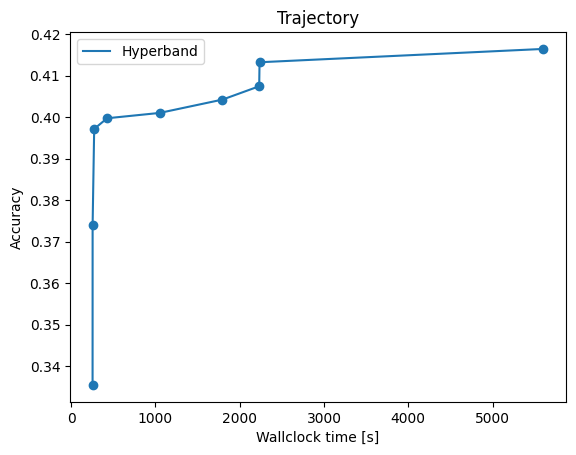

Timer unit: 1e-09 s

Total time: 6094.81 s
File: /var/folders/w0/pq4q2kj50fvdt6t_4y4gqfvw0000gn/T/ipykernel_6045/593856201.py
Function: main at line 4

Line #      Hits         Time  Per Hit   % Time  Line Contents
     4                                           def main():
     5                                           
     6                                               
     7         1    1275000.0    1e+06      0.0      CNN32 = CNN32Wrapper()
     8                                           
     9         1          0.0      0.0      0.0      facades: list[AbstractFacade] = []
    10         2       4000.0   2000.0      0.0      for intensifier_object in [Hyperband]:
    11                                                   # Define our environment variables
    12                                                   
    13         2      32000.0  16000.0      0.0          scenario = Scenario(
    14         1    1453000.0    1e+06      0.0              CNN32.configspace,
    15

In [43]:
from line_profiler import LineProfiler
from pathlib import Path
# @timeout(1800)
def main():

    
    CNN32 = CNN32Wrapper()

    facades: list[AbstractFacade] = []
    for intensifier_object in [Hyperband]:
        # Define our environment variables
        
        scenario = Scenario(
            CNN32.configspace,
            walltime_limit=14400,  # After 3600 seconds, we stop the hyperparameter optimization
            output_directory=Path("smac_hyperband_output_budget_4hr_CNN_2l_15classes"),
            n_trials=10000,  # Evaluate max 500 different trials
            min_budget=100,  # Train the MLP using a hyperparameter configuration for at least 5 epochs
            # max_budget=25,  # Train the MLP using a hyperparameter configuration for at most 25 epochs
            max_budget=1000,  # only for CNN32_5layers, Resnet18
            n_workers=8,
        )


        
        # We want to run five random configurations before starting the optimization.
        initial_design = MFFacade.get_initial_design(scenario, n_configs=5)
        
        # Create our intensifier
        intensifier = intensifier_object(scenario, incumbent_selection="highest_budget")
        
        # Create our SMAC object and pass the scenario and the train method
        smac = MFFacade(
            scenario,
            CNN32.fit,
            initial_design=initial_design,
            intensifier=intensifier,
            overwrite=True,
        )

        # optimize
        print("optimizing...")
        print(type(smac), "|", smac)
        opt_start_time = time.time()
        incumbent = smac.optimize()
        opt_end_time = time.time()
        print(f"opt execution time: {opt_end_time - opt_start_time} seconds")
        print("incumbent:", incumbent)
        # break
        # Get cost of default configuration
        default_cost = smac.validate(CNN32.configspace.get_default_configuration())
        print(f"Default cost ({intensifier.__class__.__name__}): {default_cost}")

        # calculate the cost of the incumbent
        incumbent_cost = smac.validate(incumbent)
        print(f"Incumbent cost ({intensifier.__class__.__name__}): {incumbent_cost}")
        print("appending...")
        facades.append(smac)
        for attr in dir(smac):
            if not attr.startswith('__'):
                print(attr, getattr(smac, attr))
    print("attempting to plot")
    print("facades:", facades)
    BO_file = "CNN32_5l_BO_results_2h.txt"
    plot_trajectory(facades)

if __name__ == "__main__":
    with open('smac_results_2h.txt', "w") as f:
        pass
    profiler = LineProfiler()
    profiler.add_function(main)
    profiler.enable()

    main()

    profiler.disable()
    profiler.print_stats()

In [16]:
runhistory_path = "smac_hyperband_output_budget_30mins_CNN_1l/ea9ce607e84ac9d8892dc67537556c5d/0/runhistory.json"

with open(runhistory_path, "r") as file:
    runhistory_data_CNN = json.load(file)

print("Length of runhistory_data_CNN:", len(runhistory_data_CNN["data"]))

configs_costs_CNN = []
for entry in runhistory_data_CNN["data"]:
    # print(entry)
    config_id = entry[0]  
    cost = entry[4]  
    configs_costs_CNN.append((entry[0], entry[4]))
    configs_costs_CNN = list(set(configs_costs_CNN))
    # if config_id == 533:# or config_id == 21:
    #     params_CNN = runhistory_data_CNN["configs"][str(config_id)]
    #     # print(entry)
    #     print(f"CNN config ID: {config_id}, Cost: {cost}, Parameters: {params_CNN}\n")


min_cost_config_CNN = []
min_cost_config_CNN = sorted(configs_costs_CNN, key=lambda x: x[1])[:5]
print("CNN min 5:")
for config_id, cost in min_cost_config_CNN:
    
    params = runhistory_data_CNN["configs"][str(config_id)]
    print(f"Config ID: {config_id}, Cost: {cost}, Parameters: {params}\n")
file.close()


Length of runhistory_data_CNN: 1096
CNN min 5:
Config ID: 686, Cost: 0.5912596401028278, Parameters: {'batch_size': 149, 'epochs': 107, 'lr_init': 0.0010056592549391394, 'solver': 'adam', 'weight_decay': 0.031179832658397792}

Config ID: 743, Cost: 0.5912596401028278, Parameters: {'batch_size': 149, 'epochs': 110, 'lr_init': 0.0010056592549391394, 'solver': 'adam', 'weight_decay': 0.031179832658397792}

Config ID: 339, Cost: 0.5912596401028278, Parameters: {'batch_size': 149, 'epochs': 50, 'lr_init': 0.0010056592549391394, 'solver': 'adam', 'weight_decay': 0.031179832658397792}

Config ID: 803, Cost: 0.5912596401028278, Parameters: {'batch_size': 149, 'epochs': 45, 'lr_init': 0.0010053982129999324, 'solver': 'adam', 'weight_decay': 0.031179832658397792}

Config ID: 609, Cost: 0.5912596401028278, Parameters: {'batch_size': 149, 'epochs': 84, 'lr_init': 0.0010056592549391394, 'solver': 'adam', 'weight_decay': 0.031179832658397792}



In [17]:
runhistory_path_RES = "smac_hyperband_output_budget_2hr_CNN_1l/11aa105c88868f380de6b9281f5ba8cf/0/runhistory.json"

with open(runhistory_path_RES, "r") as file:
    runhistory_data_RES = json.load(file)

print("Length of runhistory data:", len(runhistory_data_RES["data"]))

configs_costs_RES = []
for entry in runhistory_data_RES["data"]:
    config_id = entry[0]  
    cost = entry[4]
    configs_costs_RES.append((entry[0], entry[4]))
    configs_costs_RES = list(set(configs_costs_RES))
    # if config_id == 11:
    #     params = runhistory_data_RES["configs"][str(config_id)]
    #     # print(entry)
    #     print(f"Resnet Config ID: {config_id}, Cost: {cost}, Parameters: {params}\n")

min_cost_config_RES = []
min_cost_config_RES = sorted(configs_costs_RES, key=lambda x: x[1])[:5]
print(type(min_cost_config_RES))
print("Resnet min 5:")
for config_id, cost in min_cost_config_RES:
    
    params = runhistory_data_RES["configs"][str(config_id)]
    print(f"Config ID: {config_id}, Cost: {cost}, Parameters: {params}\n")
file.close()

Length of runhistory data: 2084
<class 'list'>
Resnet min 5:
Config ID: 1566, Cost: 0.5636246786632391, Parameters: {'batch_size': 778, 'epochs': 62, 'lr_init': 0.001076436040130446, 'solver': 'adam', 'weight_decay': 0.03479388735247863}

Config ID: 1420, Cost: 0.5636246786632391, Parameters: {'batch_size': 778, 'epochs': 63, 'lr_init': 0.001076436040130446, 'solver': 'adam', 'weight_decay': 0.034909839530086556}

Config ID: 1262, Cost: 0.5636246786632391, Parameters: {'batch_size': 778, 'epochs': 63, 'lr_init': 0.001114768117607331, 'solver': 'adam', 'weight_decay': 0.034712746766823115}

Config ID: 948, Cost: 0.5636246786632391, Parameters: {'batch_size': 779, 'epochs': 63, 'lr_init': 0.0010724461462085723, 'solver': 'adam', 'weight_decay': 0.034425762510666834}

Config ID: 1470, Cost: 0.5636246786632391, Parameters: {'batch_size': 778, 'epochs': 62, 'lr_init': 0.001076436040130446, 'solver': 'adam', 'weight_decay': 0.03490797085733815}

